In [28]:
import pyccl as ccl
from scipy.integrate import odeint
import MGrowth as mg
import scipy

In [2]:
params = {
    'omega_cdm'     :  [0.315-0.05],
    'As'            :  [np.exp(3.07)*1.e-10],
    'omega_baryon'  :  [0.05],
    'ns'            :  [0.96],
    'hubble'        :  [0.67],
    'neutrino_mass' :  [0.0],
    'w0'            :  [-1.0],
    'wa'            :  [0.0],
    'log10TAGN'     :  [7.6],
    'z'             :  [0.]
}
emulator_HM = hmcodeemu.Matter_powerspectrum()

k_lin_HM, pk_lin_total_HM = emulator_HM.get_linear_pk(nonu=False, **params)
k_lin_HM, pk_lin_nonu_HM = emulator_HM.get_linear_pk(nonu=True, **params)

k_nonlin_HM, pk_nonlin_total_HM = emulator_HM.get_nonlinear_pk(nonu=False, baryonic_boost=False, **params)



NameError: name 'np' is not defined

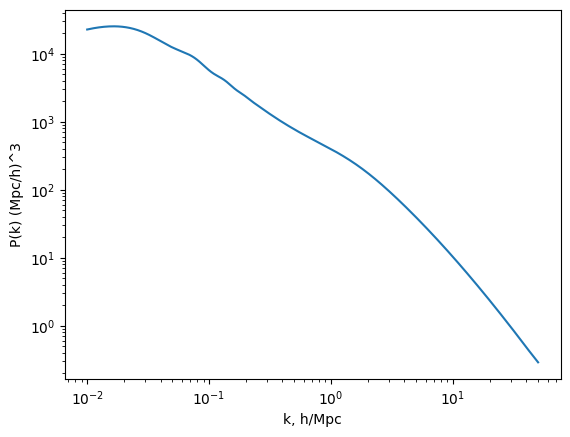

In [3]:
plt.loglog(k_nonlin_HM, pk_nonlin_total_HM[0])
plt.xlabel("k, h/Mpc")
plt.ylabel("P(k) (Mpc/h)^3")
plt.show()

# Testing

In [86]:
import MGEmu as mgemu
import matplotlib.pyplot as plt
import numpy as np

emulator_MGEmu = mgemu.MG_boost(model='gamma')

# NL matter power spectra
def P_k_NL_gammaparam(gamma, q1, GR_pk2D_obj,cosmo, MGparams, k, a):
    
    # gamma screening emulator - get boost
    cosmo_params = {
    'Omega_m'     :  [cosmo["Omega_m"]],
    'As'            :  [cosmo["A_s"]],
    'Omega_b'  :  [cosmo["Omega_b"]],
    'ns'            :  [cosmo["n_s"]],
    'H0'        :  [100*cosmo["h"]],
    'Omega_nu' :  [0.0],
    'gamma'  :  [gamma],
    'q1'  :  [q1],
    'z'  :  [1/a - 1]}

    k_values_MGEmu, boost_MGEmu = emulator_MGEmu.get_nonlinear_boost(**cosmo_params)

    k_max = k_values_MGEmu[-1]
    B_kmax = boost_MGEmu[0][-1]
    B_dash_kmax = (np.gradient(boost_MGEmu[0])/np.gradient(k_values_MGEmu))[-1]
    
    # Power law
    n = B_dash_kmax/B_kmax * k_max
    A = B_kmax / k_max**n
    pkratio = np.zeros(len(k))
    
    pkratio[k > k_max] = A * k[k > k_max] ** n
    pkratio[k <= k_max] = np.interp(k[k <= k_max],k_values_MGEmu[113:], boost_MGEmu[0][113:])
    
    # Get GR power spectrum
    
    #Pk_ccl = GR_pk2D_obj.__call__(k*cosmo["h"], a=a) # units (Mpc)^3
    return pkratio#*Pk_ccl

    

Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


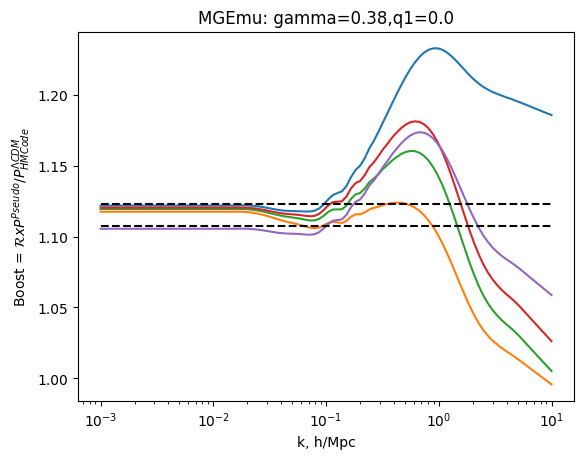

In [118]:
k = np.logspace(-3,1,100)
# Define cosmology
cosmo_universe = ccl.Cosmology(Omega_c = 0.31, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)


fR_universe = 0.0
H0rc_universe = 0.0
MGParam_universe = [H0rc_universe,fR_universe,0,0,0]

plt.semilogx(k, P_k_NL_gammaparam(0.38,2.0,None,cosmo_universe, MGParam_universe, k, 1))
plt.semilogx(k, P_k_NL_gammaparam(0.38,0.35,None,cosmo_universe, MGParam_universe, k, 1))
plt.semilogx(k, P_k_NL_gammaparam(0.38,0.55,None,cosmo_universe, MGParam_universe, k, 1))
plt.semilogx(k, P_k_NL_gammaparam(0.38,0.65,None,cosmo_universe, MGParam_universe, k, 1))
plt.semilogx(k, P_k_NL_gammaparam(0.4,0.76,None,cosmo_universe, MGParam_universe, k, 1))

plt.plot(k, np.ones(len(k))*P_k_gamma_lin(cosmo_universe, 0.38, 0.1, 1), "k--")
plt.plot(k, np.ones(len(k))*P_k_gamma_lin(cosmo_universe, 0.4, 0.1, 1), "k--")

plt.title("MGEmu: gamma=0.38,q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("Boost = $\mathcal{R} x P^{Pseudo}/P^{\Lambda  CDM}_{HMCode}$")
plt.show()

In [100]:
"""Linear matter power spectra gamma param"""

# dimensionless hubble parameter in GR
def E_norad(cosmoMCMCStep, a):
    Omg_r = 0#cosmoMCMCStep["Omega_g"]*(1+ 3.046*7/8 * (4/11)**(7/8))
    return np.sqrt(cosmoMCMCStep["Omega_m"]/a**3 +Omg_r/a**4 + (1 - cosmoMCMCStep["Omega_m"] - Omg_r))


# mu(k,a) = mu(a) in nDGP (modified gravity parametrization parameter)
def mu_gammaparam(gamma0, cosmo, a):    
    #gamma1 = 0.0
    Omg_m = cosmo["Omega_m"]*a**(-3)/E_norad(cosmo, a)**2
    #gamma = gamma0 + gamma1*(a+ 1/a -2)
    
    #mu = 2/3*Omg_m**(gamma-1) * (gamma1*(a-1/a)*np.log(Omg_m) + Omg_m**gamma + 2 -3*gamma + 3*(gamma-0.5)*Omg_m)
    mu_const = 2/3*Omg_m**(gamma0-1) * (Omg_m**gamma0 + 2 -3*gamma0 + 3*(gamma0-0.5)*Omg_m)
    #mu = 2/3*Omg_m**(gamma-1) *gamma1*(a-1/a)*np.log(Omg_m) + mu_const
    return mu_const

def solverGrowth_gammaparam(y,a,cosmo, gamma0):
    E_val = E_norad(cosmo, a)
    D , a3EdDda = y
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmo["Omega_m"]*D*(mu_gammaparam(gamma0, cosmo, a))/(2*E_val*a**2)]
    return ydot
    
def P_k_gamma_lin(cosmo, gamma0, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    input MGparams (array) -> Modified gravity parameters ([Omega_rc, fR0, n,mu])
    
    output Pk_nDGP (array) -> linear matter power spectrum for nDGP gravity, units (Mpc)^3
    """
    
    # Get growth factor in nDGP and GR
    
    a_solver = np.linspace(1/50,1,100)
    Soln = odeint(solverGrowth_gammaparam, [a_solver[0], (E_norad(cosmo, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(cosmo,gamma0), mxstep=int(1e4))
    
    Delta = Soln.T[0]
    
    Soln = odeint(solverGrowth_gammaparam, [a_solver[0], (E_norad(cosmo, a_solver[0])*a_solver[0]**3)], a_solver,\
                  args=(cosmo,0.55), mxstep=int(1e4))
    
    Delta_GR = Soln.T[0]

    # Get Pk linear in GR
    
    #Pk_GR = GR_pk2D_obj.__call__(k=k, a=a)

    # find the index for matter domination)
    #idx_mdom = np.argmax(a_solver**(-3) / E(cosmo, a_solver)**2)          
    idx_mdom = 0
    # get normalization at matter domination
    Delta_MG_49 = Delta[idx_mdom]
    Delta_GR_49 = Delta_GR[idx_mdom]
    return np.interp(a, a_solver, (Delta / Delta_MG_49) **2 / (Delta_GR / Delta_GR_49)**2) #* Pk_GR  # units (Mpc)^3


In [101]:
### Compare with MGgrowth from Maria Tsedrik

z = np.flip(np.linspace(0.0,2.5,50))

background ={'Omega_m':cosmo_universe["Omega_m"],
            'h' :cosmo_universe["h"],
            'w0': -1.0,
            'wa': 0.0,
            'a_arr': (1/(z+1))}

cosmo1 = mg.LCDM(background)
gamma = 0.8
cosmo2 = mg.Linder_gamma(background)

D_LCDM, f_LCDM = cosmo1.growth_parameters()
D_g, f_g = cosmo2.growth_parameters(gamma)

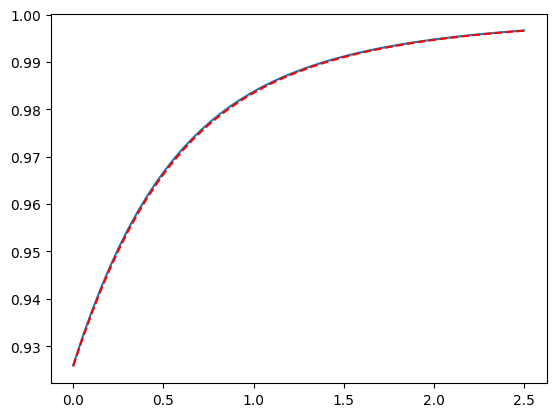

In [102]:

plt.plot(z, np.sqrt(P_k_gamma_lin(cosmo_universe, gamma, 0.1, 1/(z+1))))
plt.plot(z, D_g/D_LCDM, "r--")


## Functions for Likelihood

In [ ]:
def P_k_NL_gammaparam(GR_pk2D_obj,cosmo, MGparams, k, a):
    
    # gamma screening emulator - get boost
    cosmo_params = {
    'Omega_m'     :  [cosmo["Omega_m"]],
    'As'            :  [cosmo["A_s"]],
    'Omega_b'  :  [cosmo["Omega_b"]],
    'ns'            :  [cosmo["n_s"]],
    'H0'        :  [100*cosmo["h"]],
    'Omega_nu' :  [0.0],
    'gamma'  :  [0.4],
    'q1'  :  [0.76],
    'z'  :  [1/a - 1]}

    # Turn k into units of h/Mpc
    k = k/cosmo["h"]
    
    k_values_MGEmu, boost_MGEmu = emulator_MGEmu.get_nonlinear_boost(**cosmo_params)

    k_max = k_values_MGEmu[-1]
    B_kmax = boost_MGEmu[0][-1]
    B_dash_kmax = (np.gradient(boost_MGEmu[0])/np.gradient(k_values_MGEmu))[-1]
    
    # Power law
    n = B_dash_kmax/B_kmax * k_max
    A = B_kmax / k_max**n
    pkratio = np.zeros(len(k))
    
    pkratio[k > k_max] = A * k[k > k_max] ** n
    pkratio[k <= k_max] = np.interp(k[k <= k_max],k_values_MGEmu[113:], boost_MGEmu[0][113:])
    
    # Get GR power spectrum
    
    Pk_ccl = GR_pk2D_obj.__call__(k*cosmo["h"], a=a) # units (Mpc)^3
    return pkratio*Pk_ccl


In [ ]:
# dimensionless hubble parameter in GR
def E_norad(cosmoMCMCStep, a):
    Omg_r = 0#cosmoMCMCStep["Omega_g"]*(1+ 3.046*7/8 * (4/11)**(7/8))
    return np.sqrt(cosmoMCMCStep["Omega_m"]/a**3 +Omg_r/a**4 + (1 - cosmoMCMCStep["Omega_m"] - Omg_r))


# mu(k,a) = mu(a) in gamma param
def mu_gammaparam(gamma0, cosmo, a):    
    #gamma1 = 0.0
    Omg_m = cosmo["Omega_m"]*a**(-3)/E_norad(cosmo, a)**2
    #gamma = gamma0 + gamma1*(a+ 1/a -2)
    
    #mu = 2/3*Omg_m**(gamma-1) * (gamma1*(a-1/a)*np.log(Omg_m) + Omg_m**gamma + 2 -3*gamma + 3*(gamma-0.5)*Omg_m)
    mu_const = 2/3*Omg_m**(gamma0-1) * (Omg_m**gamma0 + 2 -3*gamma0 + 3*(gamma0-0.5)*Omg_m)
    #mu = 2/3*Omg_m**(gamma-1) *gamma1*(a-1/a)*np.log(Omg_m) + mu_const
    return mu_const

def solverGrowth_gammaparam(y,a,cosmo, gamma0):
    E_val = E_norad(cosmo, a)
    D , a3EdDda = y
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmo["Omega_m"]*D*(mu_gammaparam(gamma0, cosmo, a))/(2*E_val*a**2)]
    return ydot
    
def P_k_gamma_lin(GR_pk2D_obj,cosmo, MGparams, k, a):
    
    # Get growth factor in nDGP and GR
    
    a_solver = np.linspace(1/50,1,100)
    Soln = odeint(solverGrowth_gammaparam, [a_solver[0], (E_norad(cosmo, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(cosmo,0.4), mxstep=int(1e4))
    
    Delta = Soln.T[0]
    
    Soln = odeint(solverGrowth_gammaparam, [a_solver[0], (E_norad(cosmo, a_solver[0])*a_solver[0]**3)], a_solver,\
                  args=(cosmo,0.55), mxstep=int(1e4))
    
    Delta_GR = Soln.T[0]

    # Get Pk linear in GR
    
    Pk_GR = GR_pk2D_obj.__call__(k=k, a=a)

    idx_mdom = 0
    
    # get normalization at matter domination
    Delta_MG_49 = Delta[idx_mdom]
    Delta_GR_49 = Delta_GR[idx_mdom]
    return np.interp(a, a_solver, (Delta / Delta_MG_49) **2 / (Delta_GR / Delta_GR_49)**2) * Pk_GR  # units (Mpc)^3
